In [1]:
import numpy as np
import pandas as pd
import sqlite3

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import matplotlib.ticker as mtick

# SQLite query function (used throughout notebook)
DATABASE_DIR = "data/subway_records.db"
def sql_query(query, db_dir=DATABASE_DIR):
    """Query wrapper to ensure sqlite connection is always closed."""

    conn = sqlite3.connect(db_dir)
    df = pd.read_sql(query, conn)
    conn.close()

    return(df)

# Service patterns

## Identifying dominant patterns

Let's start by aggregating the number of trains ran in 2024-2025 along each service pattern (stop path ID), to see which patterns are the most important.

In [2]:
stop_path_ids = sql_query(
    """
    SELECT
        "Stop Path ID",
        "Origin Station Name",
        "Destination Station Name",
        "Number of Stops",
        SUM("Scheduled Trains") AS scheduled_trains,
        SUM("Actual Trains") AS actual_trains
    FROM running_times
    WHERE "Line" = 'B'
    GROUP BY "Stop Path ID" 
    ORDER BY scheduled_trains DESC;    
    """
)

stop_path_ids.head(n=12)

,Stop Path ID,Origin Station Name,Destination Station Name,Number of Stops,scheduled_trains,actual_trains
0,B-S-D03-D40-2,BEDFORD PARK BLVD,BRIGHTON BEACH,37,19878.0,17561.0
1,B-N-D40-D13-1,BRIGHTON BEACH,145TH STREET,27,16840.0,14431.0
2,B-N-D40-D03-2,BRIGHTON BEACH,BEDFORD PARK BLVD,37,16648.0,14655.0
3,B-S-D13-D40-2,145TH STREET,BRIGHTON BEACH,27,14638.0,13037.0
4,B-S-D03-D40-9,BEDFORD PARK BLVD,BRIGHTON BEACH,43,9349.0,7691.0
5,B-N-D40-D03-13,BRIGHTON BEACH,BEDFORD PARK BLVD,43,7773.0,6447.0
6,B-N-D40-D13-24,BRIGHTON BEACH,145TH STREET,33,6204.0,5122.0
7,B-S-D13-D40-19,145TH STREET,BRIGHTON BEACH,33,5018.0,4170.0
8,B-N-D40-D04-1,BRIGHTON BEACH,KINGSBRIDGE ROAD,35,1012.0,697.0
9,B-N-D35-D13-1,KINGS HIGHWAY,145TH STREET,25,576.0,519.0


Looks like there are four main patterns based on train count (rows 0-3):
- Northbound and southbound services along the full line (including the Bronx)
- Northbound and southbound services terminating at 145 St (in Manhattan)

There are also four lesser patterns (rows 4-7) with the same origin/destination combinations, but with 6 additional stops each.

Ignore patterns <= 1000 trains

## Changes in service patterns by month

Aggregate by month now to look at these two dominant groups of service patterns:

In [3]:
# New query
spid_monthly = sql_query(
    """
    SELECT
        "Month",
        "Stop Path ID",
        "Origin Station Name",
        "Destination Station Name",
        "Number of Stops",
        SUM("Scheduled Trains") AS scheduled_trains,
        SUM("Actual Trains") AS actual_trains
    FROM running_times
    WHERE "Line" = 'B'
    GROUP BY "Month", "Stop Path ID" 
    ORDER BY scheduled_trains DESC;    
    """
)
spid_monthly["Month"] = pd.to_datetime(spid_monthly["Month"])


# Select different service patterns and aggregate
main_service_patterns = ["B-N-D40-D13-1", "B-S-D13-D40-2", "B-S-D03-D40-2", "B-N-D40-D03-2"]
aux_service_patterns = ["B-S-D03-D40-9", "B-N-D40-D03-13", "B-N-D40-D13-24", "B-S-D13-D40-19"]

main_service_trains = spid_monthly[
    spid_monthly["Stop Path ID"].isin(main_service_patterns)
].groupby(by="Month")[["scheduled_trains"]].sum()

aux_service_trains = spid_monthly[
    spid_monthly["Stop Path ID"].isin(aux_service_patterns)
].groupby(by="Month")[["scheduled_trains"]].sum()


# Combine into a single dataframe
main_service_trains = main_service_trains.rename(
    columns={"scheduled_trains": "Main service"}
)
aux_service_trains = aux_service_trains.rename(
    columns={"scheduled_trains": "Auxiliary service"}
)
trains_by_month = main_service_trains.join(aux_service_trains).fillna(0)


(0.0, 4924.5)

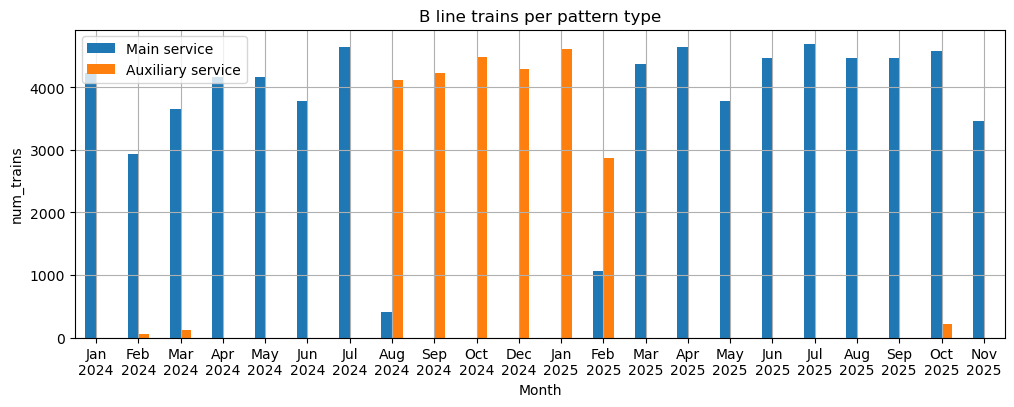

In [4]:
fig, ax = plt.subplots(figsize=(12,4))

trains_by_month.plot.bar(
    y=["Main service", "Auxiliary service"],
    ax=ax, rot=0
)
    
ax.set_title("B line trains per pattern type")
ax.set_xticklabels(trains_by_month.index.strftime('%b\n%Y'))
ax.grid()
ax.legend()
ax.set_ylabel("num_trains")    
ax.set_ylim((0, None))

Auxiliary service (the "lesser" patterns identified earlier) lines up with mid-2024 planned ROW work (identified in section on delay reporting categories), so it seems reasonable to assume the two are linked

## Service patterns by time of day

To better understand service patterns, let's look at the schedule to see how they operate in a typical day:
- Look at two stops: D03 (Bedford Park Blvd) and D13 (145 St) as proxies for the two different types of service (full and turnaround at 145 St)
- Aggregate by hour to see trains per hour (tph)

In [5]:
df = sql_query(
    """
    SELECT
        strftime('%Y-%m-%d %H', COALESCE("Departure Time", "Arrival Time")) AS hour,
        "GTFS Stop ID" AS station,
        COUNT(*) AS num_trains
    FROM schedule
    WHERE "Revenue Service" = '1'
        AND "GTFS Stop ID" IN ('D03', 'D13')
    GROUP BY strftime('%Y-%m-%d %H', COALESCE("Departure Time", "Arrival Time")), "GTFS Stop ID"
    ORDER BY "hour" ASC;
    """
)

df["hour"] = pd.to_datetime(df["hour"], format='%Y-%m-%d %H')

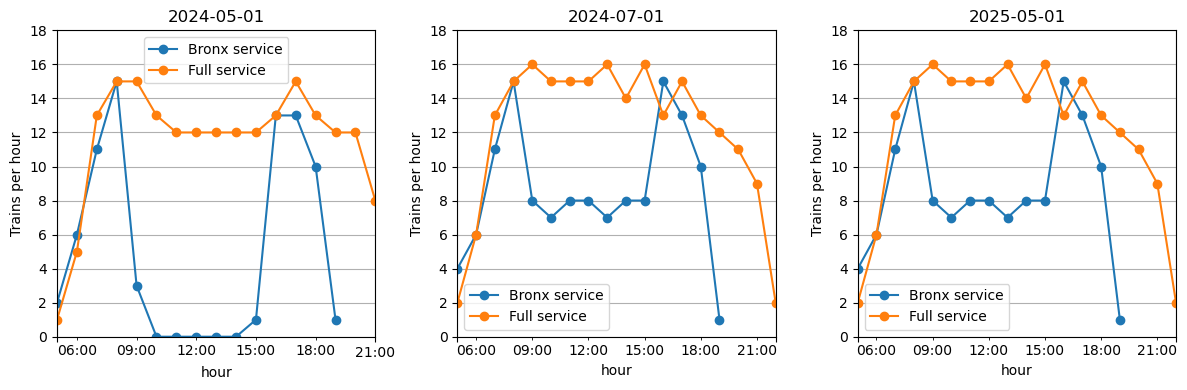

In [6]:
select_dates = ["2024-05-01", "2024-07-01", "2025-05-01"]
labels = {"D03": "Bronx service", "D13": "Full service"}

fig, ax = plt.subplots(1,3, figsize=(12,4))
for i, date in enumerate(select_dates):
    df_subset = df[df["hour"].dt.strftime("%Y-%m-%d") == date]

    # Fill in gaps in hour record
    df_subset = df_subset.set_index("hour").fillna(0)
    full_hours = pd.date_range(
        start=df_subset.index.min().floor("h"),
        end=df_subset.index.max().ceil("h"),
        freq="1h"
    )

    for s, group in df_subset.groupby(by="station"):
        group = group["num_trains"].resample("1h").sum()

        group.plot(marker="o", ax=ax[i], label=labels[s], rot=0)
    ax[i].grid()
    ax[i].legend()
    ax[i].set_ylim((0,18))
    ax[i].set_title(date)
    ax[i].set_ylabel("Trains per hour")

fig.tight_layout()

The above plot looks at tph at Bedford Park Blvd (blue) and 145 St (orange) for each hour on a typical day. The three subplots represent different dates to track evolution over time.

Service patterns appear to have changed starting in July 2024 to increase service midday.

# Delays and on-time performance

Visualize topline performance through:
- On-time performance, defined as 1 - (# delays)/(# scheduled trains)
- Service delivered, defined as (# actual trains)/(# scheduled trains)

Get this data by joining the delays data with the running_times data

In [ ]:
# Query local SQLite database
df_performance = sql_query(
    """
    WITH num_trains AS (
        SELECT
            "Month",
            SUM("Scheduled Trains") AS scheduled_trains,
            SUM("Actual Trains") AS actual_trains
        FROM running_times
        WHERE "Line" = 'B'
        GROUP BY "Month"
    ),
    agg_delays AS (
        SELECT
            "month",
            SUM("delays") AS total_delays
        FROM delays
        WHERE "Line" = 'B'
        GROUP BY "month"
    )
    SELECT 
        nt.Month, 
        nt.scheduled_trains,
        nt.actual_trains,
        COALESCE(ad.total_delays, 0) AS total_delays,
        1 - (COALESCE(ad.total_delays, 0) / NULLIF(nt.scheduled_trains, 0)) AS on_time_performance,
        (nt.actual_trains / NULLIF(nt.scheduled_trains, 0)) AS service_delivered
    FROM num_trains nt
    LEFT JOIN agg_delays ad ON ad.month = nt.Month
    ORDER BY nt.Month ASC;
    """
)

df_performance["Month"] = pd.to_datetime(df_performance["Month"])

df_performance.head()

,Month,scheduled_trains,actual_trains,"COALESCE(ad.total_delays, 0)",on_time_performance,service_delivered
0,2024-01-01,4312.0,3674.0,1384.0,0.679035,0.852041
1,2024-02-01,3729.0,3198.0,1160.0,0.688925,0.857603
2,2024-03-01,4002.0,3470.0,1311.0,0.672414,0.867066
3,2024-04-01,4306.0,3894.0,1247.0,0.710404,0.904320
4,2024-05-01,4307.0,3747.0,1227.0,0.715115,0.869979


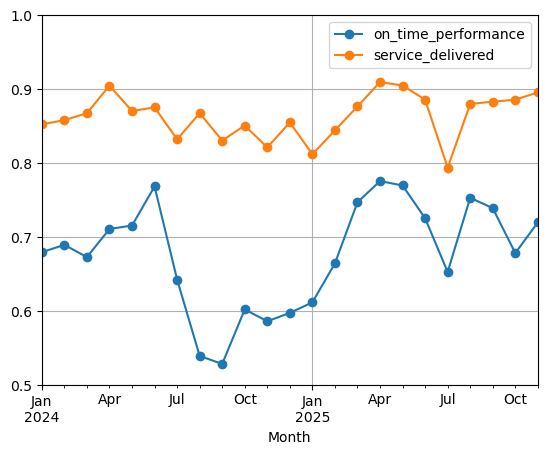

In [3]:
fig, ax = plt.subplots()

df_performance.plot(x="Month", y=["on_time_performance", "service_delivered"],
                    marker='o',
                    ax=ax)

ax.set_ylim((0.5,1))
ax.grid()

Both metrics seem slightly better in 2025 vs. 2024, even discounting the dip aligning with ROW work/local service patterns. Ignoring the dip in July (is this a typical annual pattern?)

Aggregate over three time periods for simplicity in presentation:
- Original service (Jan - Jul 2024)
- Local service/ROW work (Aug 2024 - Feb 2025)
- Increased service (Mar - Dec 2025)

In [9]:
# Boundaries for time bins
bins = pd.to_datetime([
    '2023-12-31', '2024-07-31', '2025-02-28', '2025-12-31'
])

# Sum delays and train counts
df_performance['time_bin'] = pd.cut(df_performance['Month'], bins=bins,)
binned_performance = df_performance.groupby('time_bin', observed=True)[["actual_trains","scheduled_trains","total_delays"]].sum()

# Recalculate percentages
binned_performance["on_time_performance"] = 1 - binned_performance["total_delays"]/binned_performance["scheduled_trains"]
binned_performance["service_delivered"] = binned_performance["actual_trains"]/binned_performance["scheduled_trains"]

binned_performance.head()

,actual_trains,scheduled_trains,total_delays,on_time_performance,service_delivered
time_bin,,,,,
"(2023-12-31 00:00:00, 2024-07-31 00:00:00]",25334.0,29291.0,8927.0,0.695231,0.864907
"(2024-07-31 00:00:00, 2025-02-28 00:00:00]",25459.0,30296.0,12460.0,0.588725,0.840342
"(2025-02-28 00:00:00, 2025-12-31 00:00:00]",36230.0,41246.0,11227.0,0.727804,0.878388


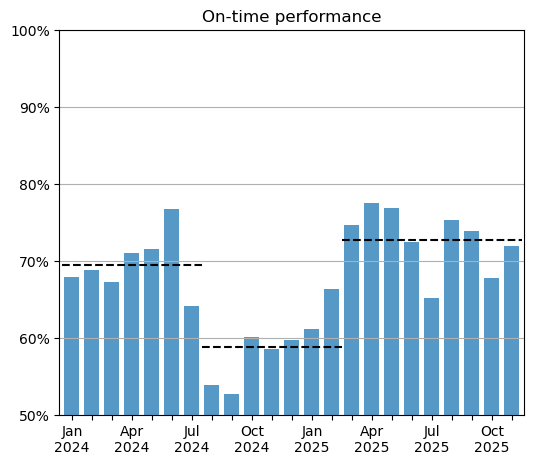

In [10]:
fig, ax = plt.subplots(figsize=(6,5))

df_performance.plot(x="Month",
                    y="on_time_performance",
                    kind="bar", rot=0,
                    width=0.75, alpha=0.75,
                    ax=ax, legend=False)

bdys = [(-0.5,6.5),(6.5,13.5),(13.5,22.5)]
for i, (index, row) in enumerate(binned_performance.iterrows()):
    ax.hlines(
        y=row["on_time_performance"],
        xmin=bdys[i][0], xmax=bdys[i][1],
        linestyle="dashed",
        linewidth=1.5,
        color="black"
    )

labels = np.where(df_performance["Month"].dt.month % 3 == 1,
                  df_performance["Month"].dt.strftime('%b\n%Y'),
                  df_performance["Month"].dt.strftime(''))
ax.set_xticklabels(labels)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlabel("")
ax.set_title("On-time performance")
ax.set_ylim((0.5,1))
ax.grid(axis='y')

Black dashed lines are the aggregates. Despite increased service frequencies, topline numbers slightly improved after the local service dip as compared to before.
- Caveat: for the scope of this assessment, I'm not going to perform uncertainty analysis on this claim

# Delay reporting categories

Let's make a stacked area plot breaking down the different delays into reporting category by month.

In [35]:
delays = sql_query(
    """ 
    SELECT
        "month",
        "reporting_category",
        "delays"
    FROM delays
    WHERE "Line" = 'B'
    ORDER BY "month" ASC;
    """
)
delays["month"] = pd.to_datetime(delays["month"])

# Make pivot dataframe
pivot_df = delays.pivot(
    index='month', 
    columns='reporting_category', 
    values='delays'
).fillna(0)

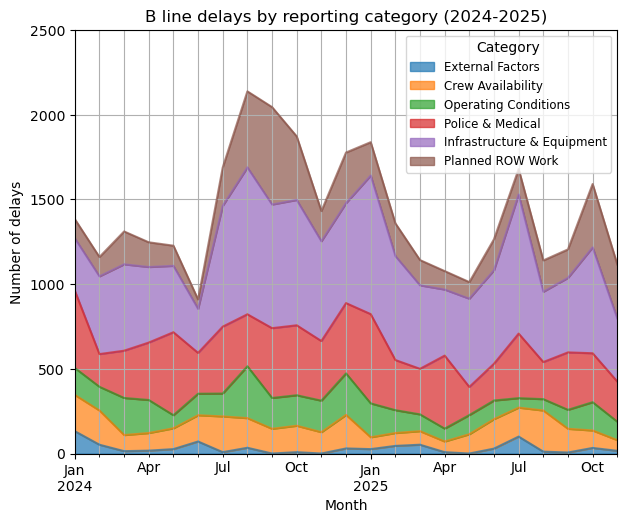

In [36]:
# Re-order categories
pivot_df = pivot_df[[
    "External Factors", "Crew Availability", "Operating Conditions",
    "Police & Medical",
    "Infrastructure & Equipment",
    "Planned ROW Work"
]]

# pivot_dt = pivot_df.div(pivot_df.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(7, 5.5))
pivot_df.plot(kind='area', ax=ax, alpha=0.7)

ax.set_title("B line delays by reporting category (2024-2025)")
ax.set_ylabel("Number of delays")
ax.set_xlabel("Month")
ax.set_ylim((0, 2500))
ax.legend(loc='upper right', title="Category", fontsize=8.5)
ax.grid(which='both')

Reduce number of categories for simpler presentation

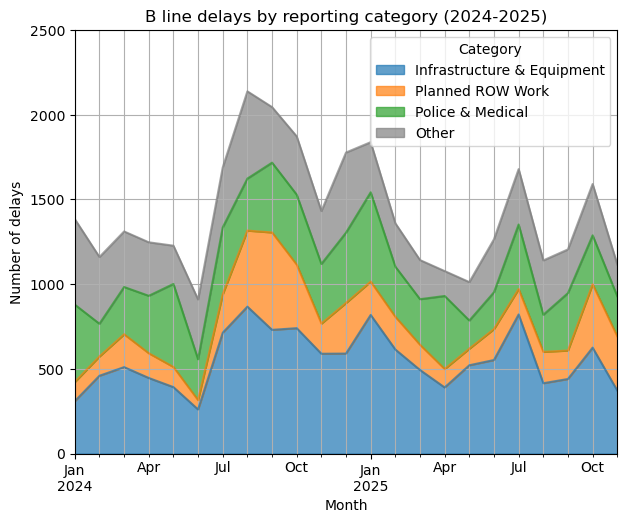

In [37]:
# Re-order categories
simple_df = pivot_df[[
    "Infrastructure & Equipment",
    "Planned ROW Work",
    "Police & Medical"
    ]].copy()
simple_df.insert(loc=3, column="Other", value=pivot_df[[
        "External Factors", "Crew Availability", "Operating Conditions"
    ]].sum(axis=1))
# simple_df["Other"] = pivot_df[["External Factors", "Crew Availability", "Operating Conditions"]].sum(axis=1)

fig, ax = plt.subplots(figsize=(7, 5.5))
simple_df.plot(kind='area', ax=ax, alpha=0.7, color=["C0", "C1", "C2", "gray"])

ax.set_title("B line delays by reporting category (2024-2025)")
ax.set_ylabel("Number of delays")
ax.set_xlabel("Month")
ax.set_ylim((0, 2500))
ax.legend(loc='upper right', title="Category")
ax.grid(which='both')

The number of delays is steady-ish, outside certain spikes that seem mostly attributable to Planned ROW Work. Quick number crunching reveals that I&E (infrastructure and equipment) delays are consistently nearly 40% of delays across the entire time span.

# Trip time analysis

Assuming OTP improvement is related to fewer fractional trains being 5+ minutes late, we should be able to see trends in the train time data directly.

This data is pretty granular/high-dimensional (month, stop path ID, and time period combined define a unique entry). Start by making an exploratory survey plot, looking at scheduled vs. actual train times for multiple different lines and time periods. See markdown below the plot for breakdown

In [19]:
trip_df = sql_query(
    """
    SELECT 
        "Month",
        "Stop Path ID",
        "Time Period",
        "Actual Trains",
        "Average Scheduled Runtime",
        "Average Actual Runtime",
        "25th Percentile Runtime",
        "75th Percentile Runtime",
        "Average Actual Runtime" - "Average Scheduled Runtime" AS avg_lag,
        "75th Percentile Runtime" - "25th Percentile Runtime" AS variability
    FROM running_times
    WHERE "Line" = 'B'
    ORDER BY "Month" ASC, "Stop Path ID" ASC;
    """
)

trip_df["Month"] = pd.to_datetime(trip_df["Month"])

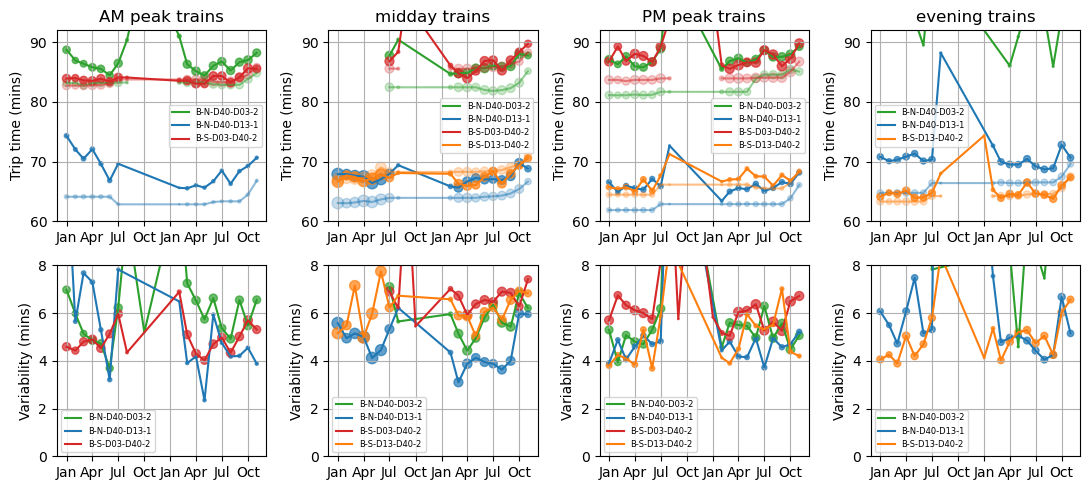

In [20]:
main_stop_path_ids = ["B-N-D40-D13-1", "B-S-D13-D40-2", "B-N-D40-D03-2", "B-S-D03-D40-2"]
main_time_periods = ["AM peak", "midday", "PM peak", "evening"]
colors = ["C0", "C1", "C2", "C3"]

fig, ax = plt.subplots(2,4, figsize=(11,5))


# Group by time period and stop path ID, to hopefully visualize these dimensions at a glance
for label, group in trip_df.groupby(["Time Period", "Stop Path ID"]):
    time_period, stop_path_id = label 
    if not (stop_path_id in main_stop_path_ids) or not (time_period in main_time_periods):
        continue
    else:
        j = main_time_periods.index(time_period)
        k = main_stop_path_ids.index(stop_path_id)
    
    ax[0,j].plot(group["Month"], group["Average Scheduled Runtime"], 
                 color=colors[k], alpha=0.5)
    ax[0,j].scatter(x=group["Month"], y=group["Average Scheduled Runtime"], s=group["Actual Trains"]/10, alpha=0.25, color=colors[k])
    ax[0,j].plot(group["Month"], group["Average Actual Runtime"], label=stop_path_id,
                 color=colors[k])
    ax[0,j].scatter(x=group["Month"], y=group["Average Actual Runtime"], s=group["Actual Trains"]/10, alpha=0.7, color=colors[k])
    ax[1,j].plot(group["Month"], group["variability"], label=stop_path_id,
                 color=colors[k])
    ax[1,j].scatter(x=group["Month"], y=group["variability"], s=group["Actual Trains"]/10, alpha=0.7, color=colors[k])

for j in range(4):
    for i in range(2):
        ax[i,j].xaxis.set_major_formatter(mdates.DateFormatter("%b"))
        ax[i,j].grid()
        ax[i,j].legend(fontsize=6)

    ax[0,j].set_title(f"{main_time_periods[j]} trains")
    ax[0,j].set_ylabel("Trip time (mins)")
    ax[0,j].set_ylim((60,92))

    ax[1,j].set_ylabel("Variability (mins)")
    ax[1,j].set_ylim((0,8))

fig.tight_layout()

This is a busy plot! *Not* meant for an executive to read. Instead, it's intentionally multidimensional, meant to be studied for several minutes to identify areas to hone in for presentation. How to read the plot:
- Rows:
    - Top row: scheduled (faint lines) vs. actual times (solid lines)
    - Bottom row: trip time variability (75th percentile - 25th percentile actual times) in minutes
- Columns represent different time periods: AM peak, midday, PM peak, evening
- Lines:
    - Colors represent the four different main service patterns (north/southbound, full line vs. turn-around at 145 St)
    - Circle sizes represent number of trains (bigger circles = more trains, data is more significant/representative)

Three things I noticed in aggregate that I now want to hone in on:
- An increase in **scheduled** train time seems at least partially responsible for reduced delays, with little reduction in actual train time
- In latter 2025, there seems to be an uptick in both scheduled and actual train times
- Variability remains flat or has small (~1 min) improvements, depending on service pattern

A good representative candidate to demonstrate these trends is midday service to/from 145 St. Let's make clean plots of this specifically:

In [21]:
# Filter rows for midday, to/from 145 St
full_service_patterns = ["B-N-D40-D13-1", "B-S-D13-D40-2"]
subset_df = trip_df[(
    trip_df["Time Period"] == "midday"
) & (
    trip_df["Stop Path ID"].isin(full_service_patterns)
)]

# Construct index and keep only useful columns
subset_df = subset_df \
.sort_values(
    by=["Stop Path ID", "Month"]
).set_index(
    ["Stop Path ID","Month"]
)[[
    "Actual Trains", "Average Scheduled Runtime", "Average Actual Runtime", "variability"
]]

df_north = subset_df.loc[full_service_patterns[0],:].resample('MS').asfreq()
df_south = subset_df.loc[full_service_patterns[1],:].resample('MS').asfreq()


# Only look at months with substantial numbers of this service pattern
df_north.loc[df_north["Actual Trains"] < 100, :] = np.nan
df_south.loc[df_south["Actual Trains"] < 100, :] = np.nan

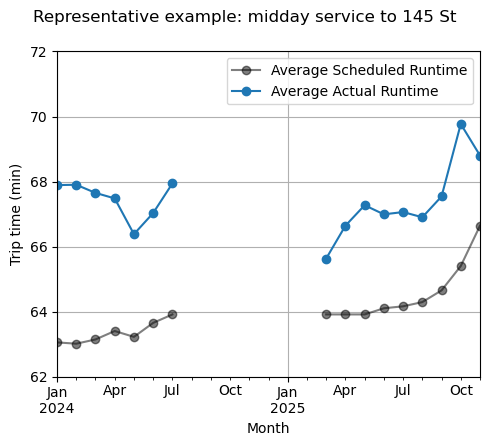

In [ ]:
# Plot of scheduled vs. actual runtime on northbound service
fig, ax = plt.subplots(figsize=(5,4.5))

df = df_north
df.plot(y="Average Scheduled Runtime",
        marker="o", color="black", alpha=0.5,
        ax=ax, zorder=2)
df.plot(y="Average Actual Runtime",
        marker="o", color="C0",
        ax=ax, zorder=2)
    
ax.grid()
ax.set_ylim((62,72))
ax.set_ylabel("Trip time (min)")
ax.legend()

fig.suptitle("Representative example: midday service to 145 St")
fig.tight_layout()

The above plot compares actual to scheduled average runtimes. The gap in the center is related to 
 With all the clutter from the earlier plot gone, we can see that there is an overall reduction in average runtime lag, at least partially due to adjustments to the schedule. You can also see the slightly concerning uptick of runtime in late 2025.

I'll also make a plot for runtime variability:

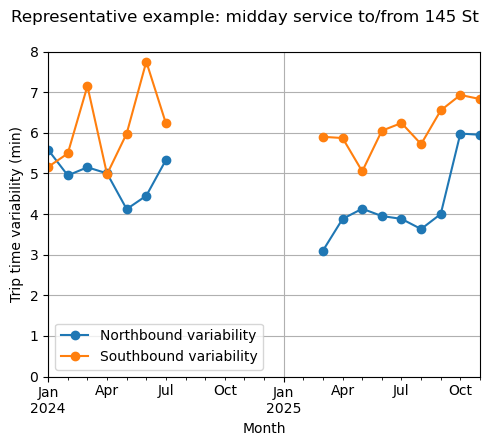

In [24]:
dfs = [df_north, df_south]
labels = ["Northbound variability", "Southbound variability"]
colors = ["C0","C1"]

# Plot of runtime variability for north- and southbound service
fig, ax = plt.subplots(figsize=(5,4.5))
for i, df in enumerate(dfs):
        df.plot(y="variability",
                marker="o", color=colors[i],
                label=labels[i],
                ax=ax, zorder=2)

    
ax.grid()
ax.set_ylim((0,8))
ax.set_ylabel("Trip time variability (min)")
ax.legend()

fig.suptitle("Representative example: midday service to/from 145 St")
fig.tight_layout()

- Northbound service sees a ~1 min reduction in variability from 2024 to 2025 (5 to 4 minutes), ignoring a spike in Oct-Nov 2025.
- Southbound service sees no such improvements. Variability is high at 6 minutes, pretty consistently, albeit with ~1 min fluctuations in either direction